# POC — Random Forest + Geometric SMOTE on mean-sampled SAR features (per-location)

Follow-up to `POC_MeanSampling.ipynb`. Consumes the per-tree artifacts it generated
(`rvi_rfdi_means.csv`: window means HH/HV/VV/VH @ W3/W5 + RVI + RFDI, + engineered `RFDI_VH`;)
**14 features, no coordinates** — and trains a **Random Forest** per location.

**Run matrix** (each location fully isolated — Palong on Palong, Serting on Serting):

| dimension | options |
|---|---|
| classes | `binary` = Healthy vs Unhealthy · `with_middle` = 3-class H/M/U |
| resampling | `gsmote` = Geometric SMOTE **on training folds only** (leakage-safe) · `class_weighted_rf` = no resampling, balanced-subsample weights (attribution baseline) |
| CV | `spatial` = GroupKFold(5) on ~220 m blocks — **honest estimate** · `random` = StratifiedKFold(5) — **optimistic reference** (spatial autocorrelation inflates it, as established in the earlier POCs) |

**Metrics**: Balanced Accuracy, per-class Recall, F1 (Unhealthy + macro), MCC — plus a confusion
matrix (counts + row-%) for **every** run, saved to `misc/POC_Results/RF_GSMOTE/`.

**G-SMOTE note.** `GeometricSMOTE` only ever shipped in imbalanced-learn ≤ 0.9 (removed later;
standalone package no longer distributed), so this notebook includes a compact faithful reference
implementation (Douzas & Bação, 2019, *Machine Learning* 108:1017–1037), self-tested below against
its degenerate cases: `deformation_factor=0` ⇒ pure random over-sampling; `truncation_factor=0`
⇒ SMOTE-like segment interpolation. Paper defaults are used: τ=1.0, δ=1.0,
`hypercube_sel='random'`, k=5.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, matthews_corrcoef,
                             recall_score, f1_score, confusion_matrix)
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore", category=UserWarning)

SEED      = 42
BLOCK_DEG = 0.002                      # ~220 m spatial blocks for honest-CV groups
N_SPLITS  = 5
RF_PARAMS = dict(n_estimators=300, random_state=SEED, n_jobs=-1)
GSMOTE    = dict(k_neighbors=5, truncation_factor=1.0, deformation_factor=1.0,
                 hypercube_sel="random")

_CANDIDATES = [
    Path("../POC_Results/MeanSampling"),                    # run from misc/notebook
    Path("misc/POC_Results/MeanSampling"),                  # run from repo root
    Path("/d/User_Stuff/Coding/MasterProject/SAR-OilPalm-Detection/misc/POC_Results/MeanSampling"),
]
DATA_DIR = next(c.resolve() for c in _CANDIDATES if (c / "rvi_rfdi_means.csv").exists())
OUT_DIR  = DATA_DIR.parent / "RF_GSMOTE"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Data :", DATA_DIR); print("Out  :", OUT_DIR)

Data : /d/User_Stuff/Coding/MasterProject/SAR-OilPalm-Detection/misc/POC_Results/MeanSampling
Out  : /d/User_Stuff/Coding/MasterProject/SAR-OilPalm-Detection/misc/POC_Results/RF_GSMOTE


## 1) Geometric SMOTE — reference implementation

Per sample: draw a minority point `x_i` and one of its `k` minority neighbours `x_zi`; build the
**selector hypercube** centered at their midpoint with per-dimension half-extent
`truncation_factor · ||x_i − x_zi||`; draw `x_s` inside it (`random` / `lower` / `upper` half);
deform from `x_i` toward `x_s` by a random factor capped at `deformation_factor`.
Multiclass is handled one-vs-rest per class (as in the SMOTE family).

In [2]:
class GeometricSMOTE:
    def __init__(self, sampling_strategy="auto", k_neighbors=5, truncation_factor=1.0,
                 deformation_factor=1.0, hypercube_sel="random", random_state=None):
        self.sampling_strategy = sampling_strategy
        self.k_neighbors = k_neighbors
        self.truncation_factor = truncation_factor
        self.deformation_factor = deformation_factor
        self.hypercube_sel = hypercube_sel
        self.random_state = random_state

    def fit_resample(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y)
        rng = np.random.default_rng(self.random_state)
        counts = pd.Series(y).value_counts()
        if self.sampling_strategy == "auto":
            n_max = counts.max()
            targets = {c: int(n_max) for c, n in counts.items() if n < n_max}
        else:
            targets = dict(self.sampling_strategy)
        Xs, ys = [X], [y]
        for cls, n_target in targets.items():
            Xc = X[y == cls]
            n_new = int(n_target - len(Xc))
            if n_new <= 0:
                continue
            k = int(min(self.k_neighbors, len(Xc) - 1))
            nbrs = NearestNeighbors(n_neighbors=k + 1).fit(Xc).kneighbors(Xc, return_distance=False)[:, 1:]
            i  = rng.integers(0, len(Xc), n_new)            # base point x_i
            zi = nbrs[i, rng.integers(0, k, n_new)]         # one of its k minority neighbours
            xi, xz = Xc[i], Xc[zi]
            d      = np.linalg.norm(xi - xz, axis=1, keepdims=True)
            center = (xi + xz) / 2.0
            half   = self.truncation_factor * d             # broadcasts over feature dims
            if self.hypercube_sel == "random":
                x_s = center + rng.uniform(-1, 1, xi.shape) * half
            elif self.hypercube_sel == "lower":
                x_s = center - rng.uniform(0, 1, xi.shape) * half
            elif self.hypercube_sel == "upper":
                x_s = center + rng.uniform(0, 1, xi.shape) * half
            else:
                raise ValueError(self.hypercube_sel)
            zeta = rng.uniform(0, 1, (n_new, 1))
            syn  = xi + zeta * self.deformation_factor * (x_s - xi)
            Xs.append(syn); ys.append(np.full(n_new, cls))
        return np.vstack(Xs), np.concatenate(ys)

In [3]:
# --- degenerate-case self-tests -------------------------------------------------
rng = np.random.default_rng(0)
Xt = np.vstack([rng.normal(0, .5, (400, 6)), rng.normal(0.8, .5, (40, 6))])
yt = np.array(["H"] * 400 + ["U"] * 40)

# (a) deformation_factor=0  =>  exact copies (random over-sampling)
X0, y0 = GeometricSMOTE(deformation_factor=0.0, random_state=0).fit_resample(Xt, yt)
assert (pd.Series(y0).value_counts() == 400).all()
assert set(map(tuple, X0[y0 == "U"])) <= set(map(tuple, Xt[yt == "U"]))

# (b) truncation_factor=0  =>  SMOTE-like interpolation: synthetic points stay inside
#     the convex hull spanned per-dimension by the original class points
X1, y1 = GeometricSMOTE(truncation_factor=0.0, random_state=0).fit_resample(Xt, yt)
assert X1[y1 == "U"].min() >= Xt[yt == "U"].min() - 1e-9
assert X1[y1 == "U"].max() <= Xt[yt == "U"].max() + 1e-9

# (c) default: classes balanced;  (d) 3-class one-vs-rest balancing
X2, y2 = GeometricSMOTE(random_state=0).fit_resample(Xt, yt)
assert (pd.Series(y2).value_counts() == 400).all()
yt3 = np.array(["H"] * 400 + ["M"] * 30 + ["U"] * 10)
X3, y3 = GeometricSMOTE(random_state=0).fit_resample(Xt, yt3)
assert (pd.Series(y3).value_counts() == 400).all()

print("GeometricSMOTE self-tests passed (ROS-degenerate, SMOTE-degenerate, binary & 3-class)")

GeometricSMOTE self-tests passed (ROS-degenerate, SMOTE-degenerate, binary & 3-class)


## 2) Load artifacts & build per-location datasets

In [4]:
df = pd.read_csv(DATA_DIR / "rvi_rfdi_means.csv")

W = (3, 5)   # window sizes fixed per POC scope
FEATS = ([f"{p}_meanW{w}" for p in ("HH", "HV", "VV", "VH") for w in W]
         + [f"RVI_meanW{w}" for w in W]
         + [f"RFDI_meanW{w}" for w in W])
for w in W:  # engineered extra (best single feature in the MeanSampling addendum)
    df[f"RFDI_VH_meanW{w}"] = (df[f"HH_meanW{w}"] - df[f"VH_meanW{w}"]) / (df[f"HH_meanW{w}"] + df[f"VH_meanW{w}"])
    FEATS.append(f"RFDI_VH_meanW{w}")

# ~220 m spatial blocks -> CV groups for the honest protocol
df["block"] = (np.floor(df.Long / BLOCK_DEG).astype(int).astype(str) + "_"
               + np.floor(df.Lat  / BLOCK_DEG).astype(int).astype(str))

CLASS_ORDER3 = ["Healthy", "Middle", "Unhealthy"]
CLASS_ORDER2 = ["Healthy", "Unhealthy"]

assert df[FEATS].isna().sum().sum() == 0, "unexpected NaNs in feature matrix"
print(f"{len(FEATS)} features:", FEATS)
for loc, sub in df.groupby("Location"):
    print(f"{loc:20s}", sub.Class.value_counts().to_dict())

14 features: ['HH_meanW3', 'HH_meanW5', 'HV_meanW3', 'HV_meanW5', 'VV_meanW3', 'VV_meanW5', 'VH_meanW3', 'VH_meanW5', 'RVI_meanW3', 'RVI_meanW5', 'RFDI_meanW3', 'RFDI_meanW5', 'RFDI_VH_meanW3', 'RFDI_VH_meanW5']
Palong_Basemap       {'Healthy': 1971, 'Middle': 493, 'Unhealthy': 200}
Serting_Basemap      {'Healthy': 1513, 'Middle': 378, 'Unhealthy': 154}


## 3) Run matrix — 2 locations × 2 class settings × 2 resampling × 2 CV protocols

All out-of-fold predictions are aggregated across folds; metrics are computed **once on the full
OOF vector** (no fold-mean smoothing), and the same OOF vectors feed the confusion matrices.

In [5]:
def run_config(loc, class_mode, resample, cv):
    sub = df[df.Location == loc]
    if class_mode == "binary":
        sub = sub[sub.Class.isin(CLASS_ORDER2)]
        order = CLASS_ORDER2
    else:
        order = CLASS_ORDER3
    X, y = sub[FEATS].to_numpy(), sub.Class.to_numpy()

    if cv == "spatial":
        splits = GroupKFold(N_SPLITS).split(X, y, sub.block.to_numpy())
    else:
        splits = StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED).split(X, y)

    y_oof = np.empty(len(y), dtype=object)
    for tr, te in splits:
        if resample == "gsmote":
            Xtr, ytr = GeometricSMOTE(random_state=SEED, **GSMOTE).fit_resample(X[tr], y[tr])
            clf = RandomForestClassifier(**RF_PARAMS)          # already balanced
        else:
            Xtr, ytr = X[tr], y[tr]
            clf = RandomForestClassifier(class_weight="balanced_subsample", **RF_PARAMS)
        clf.fit(Xtr, ytr)
        y_oof[te] = clf.predict(X[te])

    rec = dict(zip(order, recall_score(y, y_oof, labels=order, average=None, zero_division=0)))
    row = dict(location=loc.replace("_Basemap", ""), classes=class_mode,
               resampling=resample, cv=cv, n_oof=len(y),
               bal_acc=balanced_accuracy_score(y, y_oof),
               MCC=matthews_corrcoef(y, y_oof),
               recall_Healthy=rec.get("Healthy", np.nan),
               recall_Middle=rec.get("Middle", np.nan),
               recall_Unhealthy=rec.get("Unhealthy", np.nan),
               f1_Unhealthy=f1_score(y, y_oof, labels=["Unhealthy"], average="macro", zero_division=0),
               f1_macro=f1_score(y, y_oof, labels=order, average="macro", zero_division=0))
    return row, y, y_oof, order

runs, preds = [], {}
for loc in df.Location.unique():
    for class_mode in ("binary", "with_middle"):
        for resample in ("gsmote", "class_weighted_rf"):
            for cv in ("spatial", "random"):
                row, y, yo, order = run_config(loc, class_mode, resample, cv)
                runs.append(row)
                preds[(loc, class_mode, resample, cv)] = (y, yo, order)
                print(f"{row['location']:8s} {class_mode:12s} {resample:18s} {cv:7s} "
                      f"bal_acc={row['bal_acc']:.3f}  recall_U={row['recall_Unhealthy']:.3f}  MCC={row['MCC']:.3f}")

Palong   binary       gsmote             spatial bal_acc=0.483  recall_U=0.030  MCC=-0.042


Palong   binary       gsmote             random  bal_acc=0.514  recall_U=0.055  MCC=0.047


Palong   binary       class_weighted_rf  spatial bal_acc=0.498  recall_U=0.000  MCC=-0.019


Palong   binary       class_weighted_rf  random  bal_acc=0.504  recall_U=0.010  MCC=0.044


Palong   with_middle  gsmote             spatial bal_acc=0.326  recall_U=0.025  MCC=-0.025


...

Serting  binary       class_weighted_rf  random  bal_acc=0.503  recall_U=0.006  MCC=0.049


Serting  with_middle  gsmote             spatial bal_acc=0.317  recall_U=0.013  MCC=-0.038


Serting  with_middle  gsmote             random  bal_acc=0.352  recall_U=0.052  MCC=0.045


Serting  with_middle  class_weighted_rf  spatial bal_acc=0.333  recall_U=0.000  MCC=-0.006


Serting  with_middle  class_weighted_rf  random  bal_acc=0.337  recall_U=0.006  MCC=0.024


## 4) Metrics table

In [6]:
res = pd.DataFrame(runs)
res.to_csv(OUT_DIR / "rf_gs_metrics.csv", index=False)
res.round(3)

,location,classes,resampling,cv,n_oof,bal_acc,MCC,recall_Healthy,recall_Middle,recall_Unhealthy,f1_Unhealthy,f1_macro
0,Palong,binary,gsmote,spatial,2171,0.483,-0.042,0.936,NaN,0.030,0.036,0.478
1,Palong,binary,gsmote,random,2171,0.514,0.047,0.973,NaN,0.055,0.083,0.512
2,Palong,binary,class_weighted_rf,spatial,2171,0.498,-0.019,0.996,NaN,0.000,0.000,0.475
3,Palong,binary,class_weighted_rf,random,2171,0.504,0.044,0.998,NaN,0.010,0.019,0.485
4,Palong,with_middle,gsmote,spatial,2664,0.326,-0.025,0.869,0.083,0.025,0.034,0.314
5,Palong,with_middle,gsmote,random,2664,0.363,0.093,0.940,0.095,0.055,0.090,0.357
6,Palong,with_middle,class_weighted_rf,spatial,2664,0.330,-0.017,0.977,0.014,0.000,0.000,0.289
7,Palong,with_middle,class_weighted_rf,random,2664,0.345,0.078,0.988,0.032,0.015,0.029,0.313
8,Serting,binary,gsmote,spatial,1667,0.497,-0.007,0.949,NaN,0.045,0.059,0.493
9,Serting,binary,gsmote,random,1667,0.520,0.069,0.975,NaN,0.065,0.099,0.520


## 5) Confusion matrix for every run (counts + row-%)

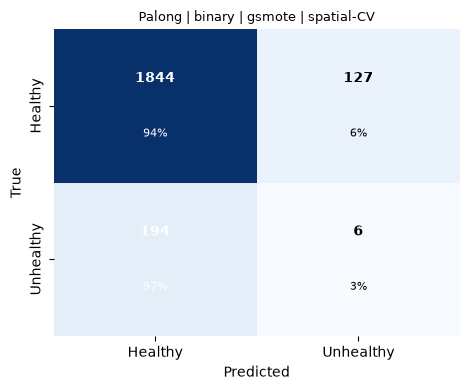

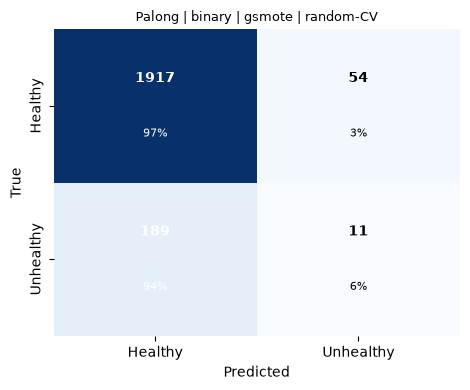

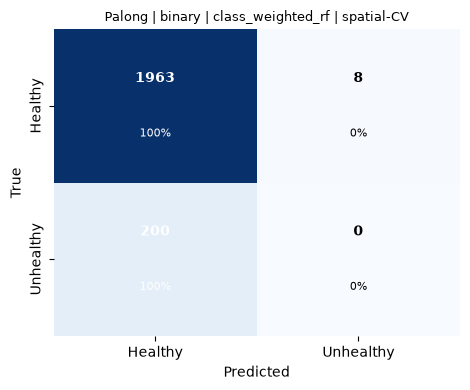

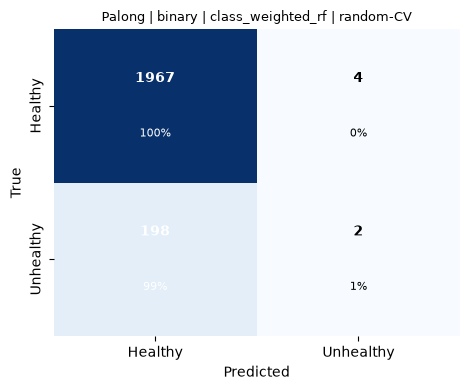

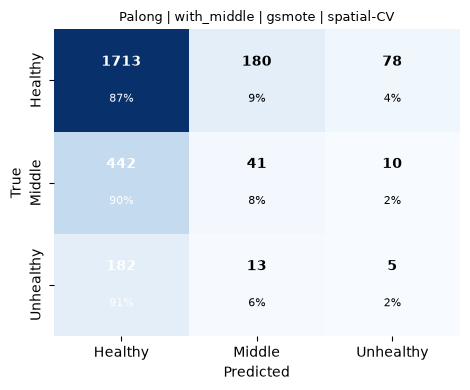

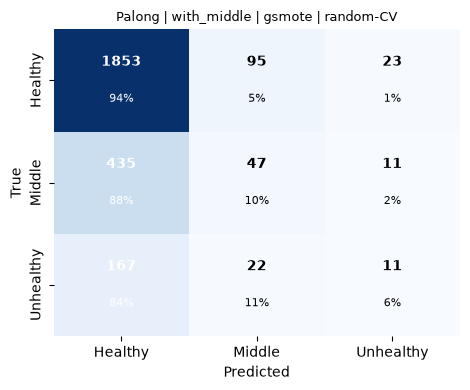

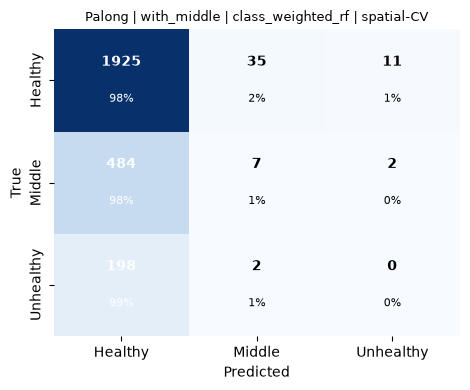

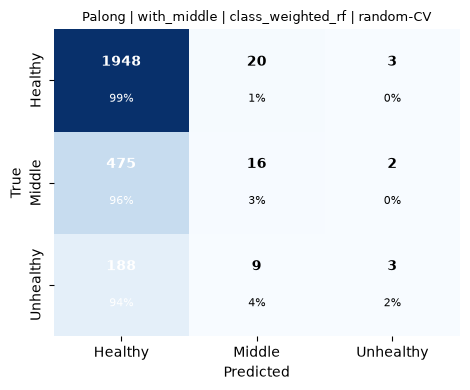

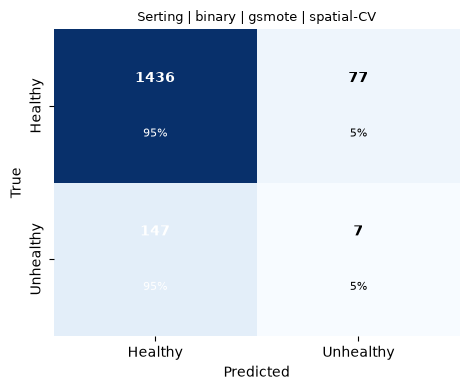

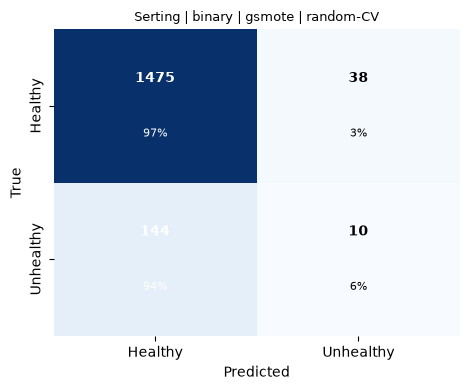

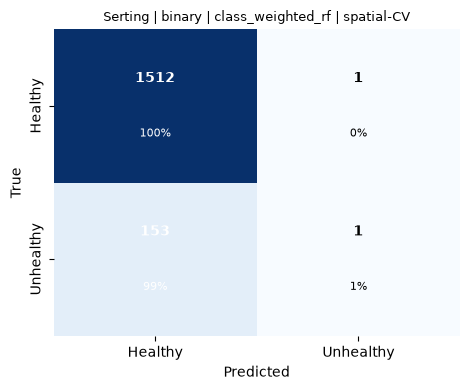

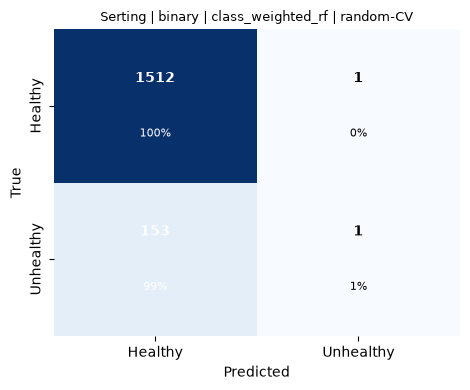

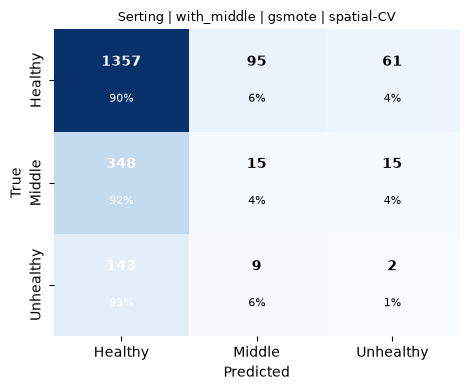

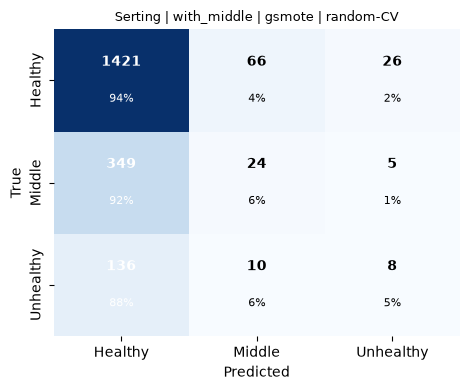

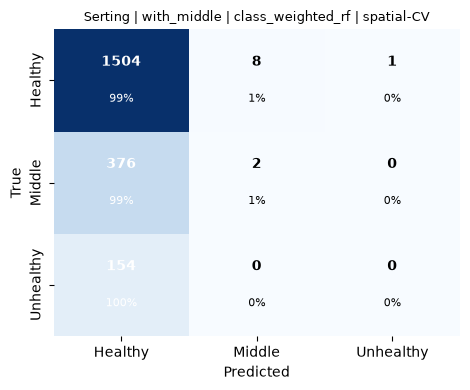

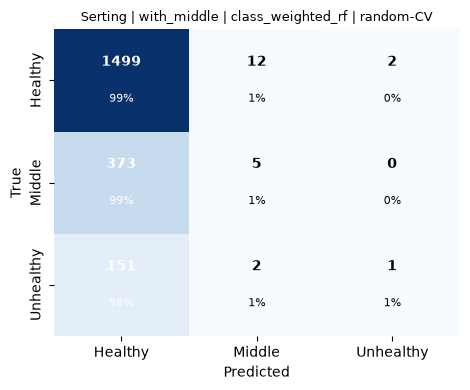

In [7]:
def plot_cm(y, yo, order, title, path):
    cm  = confusion_matrix(y, yo, labels=order)
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(4.8, 4.0))
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=False, ax=ax,
                xticklabels=order, yticklabels=order)
    for i in range(len(order)):
        for j in range(len(order)):
            col = "white" if cmn[i, j] > 0.5 else "black"
            ax.text(j + .5, i + .32, str(cm[i, j]), ha="center", va="center",
                    color=col, fontweight="bold")
            ax.text(j + .5, i + .68, f"{cmn[i, j] * 100:.0f}%", ha="center", va="center",
                    color=col, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontsize=9)
    fig.tight_layout(); fig.savefig(path, dpi=140); plt.show(); plt.close(fig)

for (loc, class_mode, resample, cv), (y, yo, order) in preds.items():
    tag = loc.replace("_Basemap", "").lower()
    plot_cm(y, yo, order,
            f"{loc.replace('_Basemap','')} | {class_mode} | {resample} | {cv}-CV",
            OUT_DIR / f"cm_{tag}_{class_mode}_{resample}_{cv}.png")

## 6) Takeaways — deltas that matter

In [8]:
piv = res.pivot_table(index=["location", "classes", "resampling"],
                      columns="cv", values=["bal_acc", "recall_Unhealthy", "MCC"])
print("spatial (honest) vs random (optimistic) side by side:")
print(piv.round(3).to_string())

gs   = res[res.resampling == "gsmote"].set_index(["location", "classes", "cv"])
base = res[res.resampling == "class_weighted_rf"].set_index(["location", "classes", "cv"])
delta = gs[["bal_acc", "recall_Unhealthy", "f1_macro", "MCC"]] \
      - base[["bal_acc", "recall_Unhealthy", "f1_macro", "MCC"]]
print("\nG-SMOTE minus class-weighted-RF baseline (positive = G-SMOTE helps):")
print(delta.round(3).to_string())

b2 = res[(res.classes == "binary") & (res.resampling == "gsmote")].set_index(["location", "cv"])
b3 = res[(res.classes == "with_middle") & (res.resampling == "gsmote")].set_index(["location", "cv"])
print("\nwith_middle (3-class) minus binary, G-SMOTE runs (did Middle add value?):")
print((b3[["bal_acc", "recall_Unhealthy", "f1_macro", "MCC"]]
       - b2[["bal_acc", "recall_Unhealthy", "f1_macro", "MCC"]]).round(3).to_string())

summary = {"notebook": "POC_RF_GSMOTE", "features": FEATS, "gsmote_params": GSMOTE,
           "rf_params": RF_PARAMS, "seed": SEED,
           "cv": {"spatial": f"GroupKFold({N_SPLITS}) on {BLOCK_DEG} deg blocks (honest)",
                  "random": f"StratifiedKFold({N_SPLITS}) (optimistic reference)"},
           "results": runs}
(OUT_DIR / "rf_gs_summary.json").write_text(json.dumps(summary, indent=2, default=str))
print("\nArtifacts in", OUT_DIR, ":", sorted(p.name for p in OUT_DIR.iterdir()))

spatial (honest) vs random (optimistic) side by side:
                                          MCC         bal_acc         recall_Unhealthy        
cv                                     random spatial  random spatial           random spatial
location classes     resampling                                                               
Palong   binary      class_weighted_rf  0.044  -0.019   0.504   0.498            0.010   0.000
                     gsmote             0.047  -0.042   0.514   0.483            0.055   0.030
         with_middle class_weighted_rf  0.078  -0.017   0.345   0.330            0.015   0.000
                     gsmote             0.093  -0.025   0.363   0.326            0.055   0.025
Serting  binary      class_weighted_rf  0.049   0.049   0.503   0.503            0.006   0.006
                     gsmote             0.069  -0.007   0.520   0.497            0.065   0.045
         with_middle class_weighted_rf  0.024  -0.006   0.337   0.333            0.006   0.

## 7) How to read this POC

- **Trust the `spatial` column only.** The `random` protocol lets neighbouring trees (whose
  intensities are spatially autocorrelated, and whose labels come in patches) leak across the
  train/test split — its numbers are inflated by construction and are shown purely as a reference
  ceiling.
- **Attribution**: each `gsmote` run has a `class_weighted_rf` twin. Any improvement must come
  from G-SMOTE, not from the RF itself.
- **`with_middle` (3-class)**: the confusion matrices show whether the annotators' Middle band is
  spectrally separable. From the MeanSampling addendum we expect it to be *spatially* defined
  (disease-front rings) rather than spectrally defined — if MCC stays near 0 under spatial CV,
  that expectation is confirmed in RF terms too.
- **Decision rule**: if G-SMOTE does not lift honest-CV Unhealthy recall / MCC meaningfully above
  the class-weighted baseline, then RF + G-SMOTE on single-date mean features is *also* not the
  direction, and the evidence for moving to multi-temporal change becomes conclusive.